# Bias-Variance Tradeoff and Learning Curves

## 📚 Learning Objectives

By completing this notebook, you will:
- Understand bias and variance in machine learning
- Analyze bias-variance tradeoff through learning curves
- Identify and handle overfitting/underfitting
- Select optimal model complexity using validation sets

## 🔗 Prerequisites

- ✅ Understanding of regression and model evaluation
- ✅ Python 3.8+ installed

---

This notebook covers practical activities from **Course 04, Unit 2**:
- Analyzing bias-variance tradeoff through learning curves
- Identifying and handling overfitting/underfitting
- Selecting optimal model complexity using validation sets

---

## Introduction to Bias-Variance Tradeoff

**Bias**: Error from overly simplistic assumptions (underfitting)
**Variance**: Error from sensitivity to small fluctuations (overfitting)
**Tradeoff**: Finding the right balance between model complexity and generalization

## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, learning_curve, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

In [2]:
# Generate sample data: a noisy sine wave
np.random.seed(42)
n_samples = 40
noise_std = 0.3

X = np.linspace(0, 10, n_samples).reshape(-1, 1)
y = np.sin(X).ravel() + noise_std * np.random.randn(n_samples)

print(f"Samples: {X.shape[0]}   Target range: [{y.min():.2f}, {y.max():.2f}]")
print(f"Noise std: {noise_std} -> irreducible (noise-floor) MSE = noise_std^2 = {noise_std**2:.3f}")
print("No model can do better than the noise floor on unseen data.")

Samples: 40   Target range: [-1.41, 1.55]
Noise std: 0.3 -> irreducible (noise-floor) MSE = noise_std^2 = 0.090
No model can do better than the noise floor on unseen data.


## Part 1: Learning Curves - Analyzing Model Performance

**A quick note on `Pipeline`** (new sklearn object): `Pipeline([('poly', PolynomialFeatures(...)), ('linear', LinearRegression())])` chains a transform step and a model into ONE object that behaves like a single model (`fit`/`predict`). We need it because `learning_curve` refits the model many times on different folds - the pipeline guarantees the polynomial features are recomputed inside every fold from that fold's training data only (no leakage between folds).


Degree 1:
  Final train MSE: 0.6161
  Final val MSE:   0.6877
Degree 4:
  Final train MSE: 0.1155
  Final val MSE:   0.1858
Degree 15:
  Final train MSE: 0.0765
  Final val MSE:   1.0324

Note: y-axis clipped at MSE = 3 - early validation points for the
degree-15 model are far off-scale (huge error on tiny training sets).


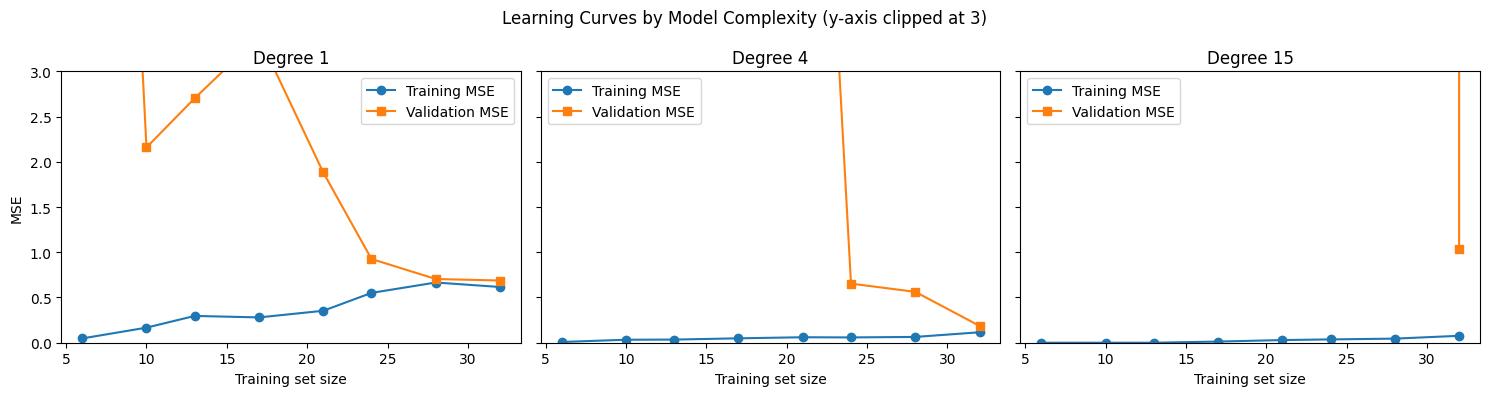

In [3]:
# Create learning curves for different model complexities
#
# NOTE on cross-validation: our X values are SORTED (0 -> 10) and
# learning_curve does not shuffle by default. Unshuffled folds would hold out
# a contiguous chunk of the x-range, forcing the model to EXTRAPOLATE far
# outside its training range - that measures extrapolation, not generalization.
# A shuffled KFold gives every fold a representative slice of the x-range.
cv = KFold(n_splits=5, shuffle=True, random_state=42)

degrees = [1, 4, 15]
models = {}

for degree in degrees:
    model = Pipeline([
        ('poly', PolynomialFeatures(degree=degree)),
        ('linear', LinearRegression())
    ])

    train_sizes, train_scores, val_scores = learning_curve(
        model, X, y, cv=cv, n_jobs=-1,
        train_sizes=np.linspace(0.2, 1.0, 8),
        scoring='neg_mean_squared_error'
    )

    models[degree] = {
        'train_sizes': train_sizes,
        'train_mean': -train_scores.mean(axis=1), 'train_std': train_scores.std(axis=1),
        'val_mean': -val_scores.mean(axis=1), 'val_std': val_scores.std(axis=1)
    }

    print(f"Degree {degree}:")
    print(f"  Final train MSE: {models[degree]['train_mean'][-1]:.4f}")
    print(f"  Final val MSE:   {models[degree]['val_mean'][-1]:.4f}")

# Plot the three learning curves side by side.
# The y-axis is clipped at MSE = 3: on tiny training sets the degree-15
# polynomial swings wildly between the few points it has seen, so its early
# validation MSE is astronomically large and would flatten everything else.
print("\nNote: y-axis clipped at MSE = 3 - early validation points for the")
print("degree-15 model are far off-scale (huge error on tiny training sets).")

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, degree in zip(axes, degrees):
    m = models[degree]
    ax.plot(m['train_sizes'], m['train_mean'], 'o-', label='Training MSE')
    ax.plot(m['train_sizes'], m['val_mean'], 's-', label='Validation MSE')
    ax.set_title(f'Degree {degree}')
    ax.set_xlabel('Training set size')
    ax.set_ylim(0, 3)
    ax.legend()
axes[0].set_ylabel('MSE')
plt.suptitle('Learning Curves by Model Complexity (y-axis clipped at 3)')
plt.tight_layout()
plt.show()

## Part 2: Identifying Overfitting and Underfitting

We now classify each model as **underfitting**, **good fit**, or **overfitting**.

The labels below are **computed from the measured errors** with explicit
thresholds - not written by hand - so the printed interpretation always
matches the numbers.

In [4]:
# Bias-variance diagnosis - labels are COMPUTED from the measured MSE values,
# so the printed interpretation can never disagree with the numbers.

NOISE_MSE = noise_std ** 2  # irreducible error (we generated the data, so we know it)

def diagnose(train_mse, val_mse):
    """Classify fit quality from final train/validation MSE.

    Rules (checked in order):
      1. OVERFITTING:  val > 2 x train AND gap > noise floor
                       (validation error far above training error)
      2. UNDERFITTING: val > 3 x noise floor
                       (even validation error is far above the best achievable)
      3. GOOD FIT:     otherwise (both errors low and close together)
    """
    gap = val_mse - train_mse
    if val_mse > 2 * train_mse and gap > NOISE_MSE:
        return "OVERFITTING (high variance)"
    if val_mse > 3 * NOISE_MSE:
        return "UNDERFITTING (high bias)"
    return "GOOD FIT (balanced bias-variance)"

print("=" * 60)
print("Bias-Variance Analysis (labels computed from the numbers)")
print("=" * 60)
print(f"Noise floor (irreducible MSE): {NOISE_MSE:.3f}")

for degree in degrees:
    train_mse = models[degree]['train_mean'][-1]
    val_mse = models[degree]['val_mean'][-1]
    gap = val_mse - train_mse
    label = diagnose(train_mse, val_mse)
    print(f"\nDegree {degree}:")
    print(f"  Train MSE: {train_mse:.4f}")
    print(f"  Val MSE:   {val_mse:.4f}")
    print(f"  Gap:       {gap:.4f}")
    print(f"  Diagnosis: {label}")

# Pick the optimal complexity by validation error
best_degree = min(models, key=lambda d: models[d]['val_mean'][-1])
best_label = diagnose(models[best_degree]['train_mean'][-1],
                      models[best_degree]['val_mean'][-1])
print("\n" + "=" * 60)
print(f"Optimal model complexity by validation MSE: degree {best_degree}")
print(f"Its computed diagnosis: {best_label}")
print("=" * 60)

Bias-Variance Analysis (labels computed from the numbers)
Noise floor (irreducible MSE): 0.090

Degree 1:
  Train MSE: 0.6161
  Val MSE:   0.6877
  Gap:       0.0716
  Diagnosis: UNDERFITTING (high bias)

Degree 4:
  Train MSE: 0.1155
  Val MSE:   0.1858
  Gap:       0.0703
  Diagnosis: GOOD FIT (balanced bias-variance)

Degree 15:
  Train MSE: 0.0765
  Val MSE:   1.0324
  Gap:       0.9559
  Diagnosis: OVERFITTING (high variance)

Optimal model complexity by validation MSE: degree 4
Its computed diagnosis: GOOD FIT (balanced bias-variance)


## Summary

### Key Concepts:
1. **Bias**: Model too simple, cannot capture patterns (underfitting)
2. **Variance**: Model too complex, memorizes noise (overfitting)
3. **Learning Curves**: Show train/validation performance vs training set size
4. **Optimal Complexity**: Balance where validation error is minimized

### How to Use:
- **Large gap between train/val**: Overfitting → reduce complexity
- **Both train/val high**: Underfitting → increase complexity
- **Both train/val similar and low**: Good model

**Reference:** Course 04, Unit 2: "Analyzing bias-variance tradeoff through learning curves" and "Identifying and handling overfitting/underfitting"
